In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
deltatheta = 2
ecart = 3
centre = 0

num_samples = 1000
real_samples = np.random.rand(num_samples)*deltatheta + (centre-deltatheta/2) - ecart/2

fake_samples = np.random.rand(num_samples)*deltatheta + (centre-deltatheta/2) + ecart/2

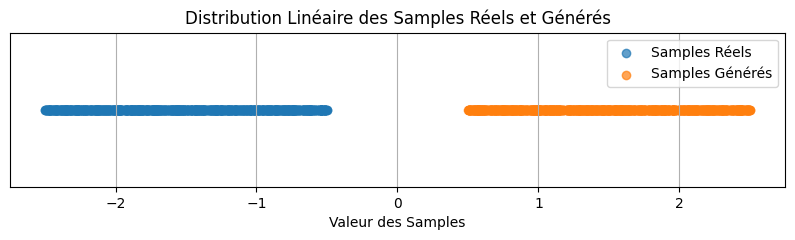

In [3]:
plt.figure(figsize=(10, 2))
plt.scatter(real_samples, np.zeros_like(real_samples), label='Samples Réels', alpha=0.7)
plt.scatter(fake_samples, np.zeros_like(fake_samples), label='Samples Générés', alpha=0.7)

plt.xlabel('Valeur des Samples')
plt.title('Distribution Linéaire des Samples Réels et Générés')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [5]:
def D(x,beta) :
  return sigmoid(-beta*(x-centre))

In [6]:
def derivative_gen_loss_ns(x,beta):
    return beta*(1 - D(x,beta))

def derivative_gen_loss_s(x,beta):
    return beta*D(x,beta)

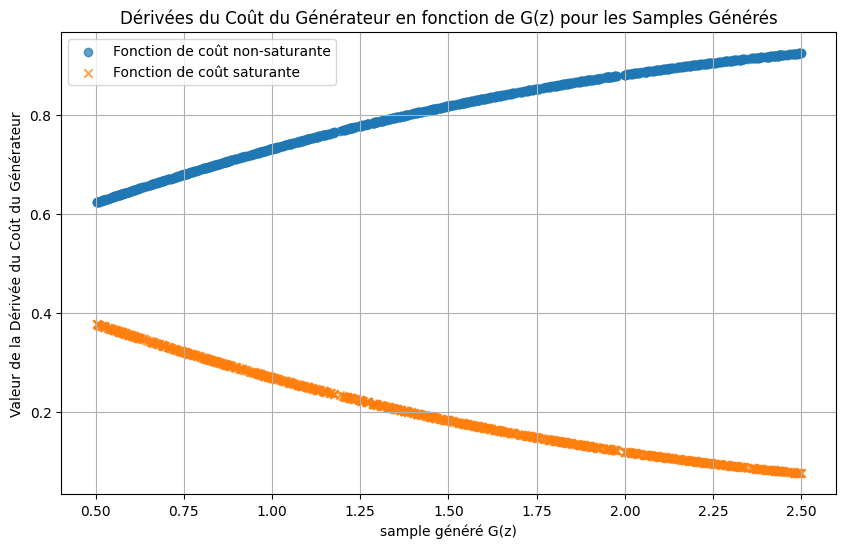

In [7]:
plt.figure(figsize=(10, 6))
beta = 1
deriv_ns = derivative_gen_loss_ns(fake_samples,beta)
deriv_s = derivative_gen_loss_s(fake_samples,beta)

plt.scatter(fake_samples, deriv_ns, label='Fonction de coût non-saturante', alpha=0.7)
plt.scatter(fake_samples, deriv_s, label='Fonction de coût saturante', alpha=0.7, marker='x')

plt.xlabel('sample généré G(z)')
plt.ylabel('Valeur de la Dérivée du Coût du Générateur')
plt.title('Dérivées du Coût du Générateur en fonction de G(z) pour les Samples Générés')
plt.legend()
plt.grid(True)
plt.show()

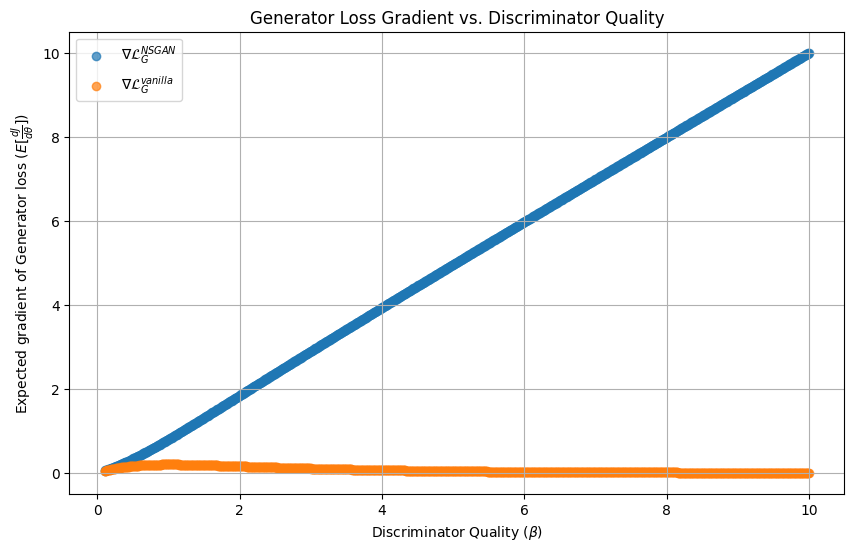

In [17]:
betas = np.linspace(0.1, 10, 1000)

Es_ns = []
Es_s = []

for beta in betas:
    deriv_ns = derivative_gen_loss_ns(fake_samples, beta)
    deriv_s = derivative_gen_loss_s(fake_samples, beta)

    E_ns = np.mean(deriv_ns)
    E_s = np.mean(deriv_s)

    Es_ns.append(E_ns)
    Es_s.append(E_s)


plt.figure(figsize=(10, 6))


plt.scatter(betas, Es_ns, label=r'$\nabla \mathcal{L}_G^{NSGAN}$', alpha=0.7)
plt.scatter(betas, Es_s, label=r'$\nabla \mathcal{L}_G^{vanilla}$', alpha=0.7)

plt.xlabel(r'Discriminator Quality $(\beta)$')
plt.ylabel(r"Expected gradient of Generator loss $(E[\frac{dJ}{d\theta}])$")
plt.title('Generator Loss Gradient vs. Discriminator Quality')
plt.legend()
plt.grid(True)
#plt.show()
plt.savefig('NSGANvsVanilla.png')
